# P-1 The Weather & Wardrobe Advisor

In [20]:
# importing request library to handel api
import requests
API_KEY = '122eec436fb4bb0b4559d953e47114'
CITY = 'London' #can be any city
URL = f'http://api.openweathermap.org/data/2.5/weather?q={CITY}&appid={API_KEY}&units=metric'#formatted string method

In [21]:
response = requests.get(URL)#recieve the response
data = response.json() #serailise the response into json format

In [22]:
if response.status_code == 200: # 200 means every thing is ok
   print(f"Successfully fetched weather for {CITY}!")
else:
    print(f"Error: {data.get('message', 'Could not connect')}")

Successfully fetched weather for London!


In [23]:
temp = data['main']['temp']
feels_like = data['main']['feels_like']
humidity = data['main']['humidity']
weather_desc = data['weather'][0]['description']

In [24]:
print(f"Current Temperature: {temp}°C")
print(f"Feels Like: {feels_like}°C")
print(f"Condition: {weather_desc.capitalize()}")

Current Temperature: 10.8°C
Feels Like: 9.89°C
Condition: Overcast clouds


In [ ]:
# actual code main logic

In [48]:
import requests

class WeatherAdviser:
    """
    An OOP approach to weather advising.
    """
    def __init__(self, api_key):
        self.api_key = api_key
        self.city = input('Enter your city: ')
        self.advice = ""

        self.url = f"http://api.openweathermap.org/data/2.5/weather?q={self.city}&appid={self.api_key}&units=metric"

        # Make the request immediately
        self.__response = requests.get(self.url)
        self.__data = self.__response.json()

    def get_advice(self):
        # 1. Error Handling Check
        if self.__response.status_code != 200:
            return f"❌ Error: {self.__data.get('message', 'Could not connect')}"

        # 2. Extract Data
        temp = self.__data['main']['temp']
        feels_like = self.__data['main']['feels_like']
        humidity = self.__data['main']['humidity']
        weather_desc = self.__data['weather'][0]['description']

        # 3. Build the Report
        report = f"--- Weather Report for {self.city.capitalize()} ---\n"
        report += f"Current Temperature: {temp}°C (Feels like: {feels_like}°C)\n"
        report += f"Humidity: {humidity}%\n"
        report += f"Condition: {weather_desc.capitalize()}\n"
        report += "-" * 30 + "\n"

        # 4. Recommendation Logic
        if temp < 5:
            report += "❄️ It's freezing! Wear a heavy parka and a scarf."
        elif 5 <= temp < 15:
            report += "🧥 Chilly weather. A trench coat or light puffer jacket is best."
        elif 15 <= temp < 25:
            report += "👕 Comfortable. A light sweater or long-sleeve shirt is perfect."
        else:
            report += "☀️ It's hot! Stick to breathable cotton clothes."

        if "rain" in weather_desc or "drizzle" in weather_desc:
            report += "\n☔ Don't forget an umbrella!"
        elif "snow" in weather_desc:
            report += "\n☃️ Wear boots; it's going to be slippery."

        return report

# Execution Logic
try:
    MY_API_KEY = "122eec436fb4bb0b4559d953e47114"
    weather = WeatherAdviser(MY_API_KEY)
    print(weather.get_advice())
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Enter your city: delhi
--- Weather Report for Delhi ---
Current Temperature: 38.05°C (Feels like: 37.44°C)
Humidity: 23%
Condition: Haze
------------------------------
☀️ It's hot! Stick to breathable cotton clothes.


# **P-2 The Automated Deal Hunter**

In [61]:
#import neccessary library
import requests
from bs4 import BeautifulSoup

#create a class called Dealhunter
class DealHunter:

  def __init__(self, url ,price):
    self.url = url
    self.price = float(price) # Convert price to float immediately

    #set header to look like a authorised user from chrome
    self.headers = {
            "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
        }

  def check_price(self):
    self.response = requests.get(self.url, headers=self.headers) # Add headers to the request
    self.soup = BeautifulSoup(self.response.text ,'lxml')

    try:
      book_name_tag = self.soup.find('h1') # Changed from 'h3' to 'h1'
      if book_name_tag:
        book_name = book_name_tag.get_text().strip()
        print(f"Book Name: {book_name}")
      else:
        book_name = "N/A"
        print("Error: Book name not found on the page.")

      price_tag = self.soup.find('p',class_='price_color')
      if price_tag:
        price_text = price_tag.get_text()
        current_price = float(price_text.replace('£', '').replace('$', '').replace('Â', '').strip()) # Convert to float
        print(f"Current Price: {current_price}")
      else:
        current_price = 0.0 # Default value if price not found
        print("Error: Current price not found on the page.")
        return "❌ Error: Could not find price information for comparison."

      availability_tag = self.soup.find('p',class_='instock availability')
      if availability_tag:
        is_available_text = availability_tag.get_text().strip()
        print(f"Availability: {is_available_text}")
      else:
        is_available_text = "N/A"
        print("Availability information not found on the page.")


      if current_price <= self.price:
        return f"🔥 DEAL FOUND! The price ({current_price}) is less than or equal to your budget ({self.price}). Buy it now!"
      elif "In stock" in is_available_text: # Check for 'In stock' in text
        return f'✅ Yes! The book "{book_name}" is in stock, but the price ({current_price}) is still above your budget ({self.price}).'
      else:
        return f"⏳ Still too expensive. Current price: {current_price}. (Budget: {self.price})"

    except Exception as e:
      print(f'An unexpected error occurred: {e}')
      return f"❌ An unexpected error occurred: {e}"


print('----------TELL ME WHICH BOOK ARE YOU LOOKING FOR AND WHAT ITS BUDGET----------')
user_url = input('--entre the url')
user_price = (input('--entre the price')) # Keep as string for input, convert inside class
deal_hunter = DealHunter(user_url,user_price)
print(deal_hunter.check_price())

----------TELL ME WHICH BOOK ARE YOU LOOKING FOR AND WHAT ITS BUDGET----------
--entre the urlhttp://books.toscrape.com/catalogue/a-light-in-the-attic_1000/index.html
--entre the price20
Book Name: A Light in the Attic
Current Price: 51.77
Availability: In stock (22 available)
✅ Yes! The book "A Light in the Attic" is in stock, but the price (51.77) is still above your budget (20.0).


# **P-3 The "Smart" Personal Finance Dashboard**

In [63]:
#importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [65]:
#creating small data
data = {
    'Date': ['2026-04-01', '2026-04-02', '2026-04-03', '2026-04-04', '2026-04-05'],
    'Description': ['Starbucks Coffee', 'Amazon Prime', 'Monthly Rent', 'Grocery Store', 'Netflix Subscription'],
    'Amount': [5.50, 14.99, 1200.00, 85.20, 19.99],
    'Category': ['Food', 'Entertainment', 'Housing', 'Food', 'Entertainment']
}

df = pd.DataFrame(data)
df.to_csv('report.csv',index=False)
print('---data is created---')
print(df)

---data is created---
         Date           Description   Amount       Category
0  2026-04-01      Starbucks Coffee     5.50           Food
1  2026-04-02          Amazon Prime    14.99  Entertainment
2  2026-04-03          Monthly Rent  1200.00        Housing
3  2026-04-04         Grocery Store    85.20           Food
4  2026-04-05  Netflix Subscription    19.99  Entertainment


-----some information of data-----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         5 non-null      object 
 1   Description  5 non-null      object 
 2   Amount       5 non-null      float64
 3   Category     5 non-null      object 
dtypes: float64(1), object(3)
memory usage: 292.0+ bytes
None
-----first 5 rows of data-----
         Date           Description   Amount       Category
0  2026-04-01      Starbucks Coffee     5.50           Food
1  2026-04-02          Amazon Prime    14.99  Entertainment
2  2026-04-03          Monthly Rent  1200.00        Housing
3  2026-04-04         Grocery Store    85.20           Food
4  2026-04-05  Netflix Subscription    19.99  Entertainment
-----last 5 rows of data-----
         Date           Description   Amount       Category
0  2026-04-01      Starbucks Coffee     5.50           Food
1  2026-04

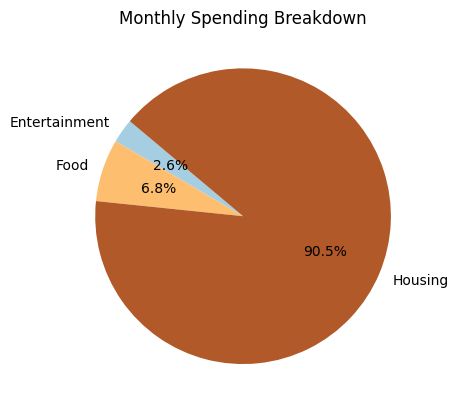

None


In [73]:
#create the class called data report summarizer

class ReportSummariser:
  def __init__(self,file_path):
    self.data = pd.read_csv(file_path)

  def summariser(self):

    print('-----some information of data-----')
    print(self.data.info())
    print('-----first 5 rows of data-----')
    print(self.data.head())
    print('-----last 5 rows of data-----')
    print(self.data.tail())
    print('-----describe data-----')
    print(self.data.describe())
    print('-----shape of data-----')
    print(self.data.shape)
    print('-----columns of data-----')
    print(self.data.columns)


    max_amount = self.data['Amount'].max()
    print(f'maximum amount ---> {max_amount}')

    min_amount = self.data['Amount'].min()
    print(f'\n minimum amount ---> {min_amount}')

    total_amount = self.data['Amount'].sum()
    print(f'\n total amount ---> {total_amount}')

    avg_amount = self.data['Amount'].mean()
    print(f'\n average amount ---> {avg_amount}')

    category_count = self.data['Category'].value_counts()
    print(f'\n category count ---> {category_count}')

    category_totals = self.data.groupby('Category')['Amount'].sum()
    print(f'\n category totals ---> {category_totals}')

    category_totals.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Paired')
    plt.title('Monthly Spending Breakdown')
    plt.ylabel('')
    plt.show()

try:
 tracker = ReportSummariser('report.csv')
 print(tracker.summariser())
except Exception as e:
  print(f'An unexpected error occurred: {e}')